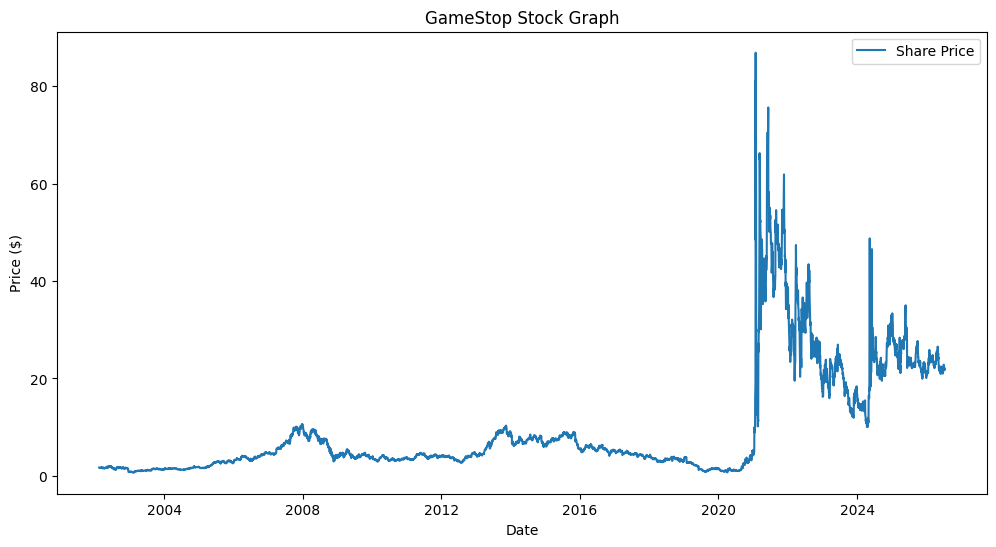

In [ ]:
make_graph(gme_data, gme_revenue, "GameStop Stock Graph")
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock_name):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(pd.to_datetime(stock_data.Date), stock_data.Close, label="Share Price")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Price ($)")
    ax1.set_title(stock_name)
    ax1.legend()
    plt.show()

make_graph(tesla_data, tesla_revenue, "Tesla Stock Graph")

url2 = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
headers = {"User-Agent": "Mozilla/5.0"}
html_data_2 = requests.get(url2, headers=headers).text
soup2 = BeautifulSoup(html_data_2, "html.parser")

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in soup2.find_all('table'):
    if 'GameStop Quarterly Revenue' in str(table):
        for row in table.find('tbody').find_all('tr'):
            col = row.find_all('td')
            if len(col) != 2:
                continue
            date = col[0].text
            revenue = col[1].text.replace('$', '').replace(',', '')
            gme_revenue = pd.concat(
                [gme_revenue, pd.DataFrame({"Date": [date], "Revenue": [revenue]})],
                ignore_index=True
            )

gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]
gme_revenue.tail()

import yfinance as yf

tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()